In [2]:
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

In [3]:
data_dir = r"C:\Users\apurb_oi8roye\Desktop\Health_sensing\Data"
dataset_dir = r"C:\Users\apurb_oi8roye\Desktop\Health_sensing\datasets"

os.makedirs(dataset_dir, exist_ok=True)

In [4]:
def load_signal(file_path):

    timestamps = []
    values = []

    with open(file_path) as f:
        lines = f.readlines()

    start_idx = 0
    for i, line in enumerate(lines):
        if line.strip() == "Data:":
            start_idx = i + 1
            break

    for line in lines[start_idx:]:

        if ";" in line:

            t, v = line.split(";")

            timestamps.append(
                pd.to_datetime(t.strip(), format="%d.%m.%Y %H:%M:%S,%f")
            )

            values.append(float(v))

    df = pd.DataFrame({
        "time": timestamps,
        "value": values
    })

    return df

In [5]:
def load_events(file_path):

    events = []

    with open(file_path) as f:

        for line in f:

            if ";" in line and "-" in line:

                parts = line.split(";")

                time_range = parts[0]
                event_type = parts[2].strip()

                start_str, end_str = time_range.split("-")

                start = pd.to_datetime(
                    start_str.strip(),
                    format="%d.%m.%Y %H:%M:%S,%f"
                )

                end_time = pd.to_datetime(
                    end_str.strip(),
                    format="%H:%M:%S,%f"
                )

                end = start.replace(
                    hour=end_time.hour,
                    minute=end_time.minute,
                    second=end_time.second,
                    microsecond=end_time.microsecond
                )

                events.append((start, end, event_type))

    return events

In [6]:
def bandpass_filter(signal, fs, low=0.17, high=0.4):

    nyquist = 0.5 * fs

    low = low / nyquist
    high = high / nyquist

    b, a = butter(4, [low, high], btype="band")

    filtered = filtfilt(b, a, signal)

    return filtered

In [7]:
def create_windows(df, fs):

    window_size = 30 * fs
    step = 15 * fs

    values = df["value"].values
    times = df["time"].values

    windows = []

    for start in range(0, len(values) - window_size, step):

        end = start + window_size

        window_signal = values[start:end]

        start_time = times[start]
        end_time = times[end]

        windows.append((start_time, end_time, window_signal))

    return windows

In [13]:
def label_window(start, end, events):

    window_duration = (end - start) / np.timedelta64(1, 's')

    for e_start, e_end, label in events:

        overlap_start = max(start, e_start)
        overlap_end = min(end, e_end)

        overlap = (overlap_end - overlap_start) / np.timedelta64(1, 's')

        if overlap > 0.5 * window_duration:
            return label

    return "Normal"

In [17]:
def process_participant(participant):

    p_path = os.path.join(data_dir, participant)

    airflow = load_signal(os.path.join(p_path, "nasal_airflow.txt"))
    thoracic = load_signal(os.path.join(p_path, "thoracic_movement.txt"))
    spo2 = load_signal(os.path.join(p_path, "spo2.txt"))

    events = load_events(os.path.join(p_path, "flow_events.txt"))

    # Apply bandpass filtering
    airflow["value"] = bandpass_filter(airflow["value"].values, 32)
    thoracic["value"] = bandpass_filter(thoracic["value"].values, 32)
    spo2["value"] = bandpass_filter(spo2["value"].values, 4)

    airflow_windows = create_windows(airflow, 32)
    thoracic_windows = create_windows(thoracic, 32)
    spo2_windows = create_windows(spo2, 4)

    dataset = []

    for i in range(len(airflow_windows)):

        start, end, af_signal = airflow_windows[i]
        _, _, th_signal = thoracic_windows[i]
        _, _, sp_signal = spo2_windows[i]

        label = label_window(start, end, events)

        dataset.append({
            "participant": participant,
            "start_time": start,
            "end_time": end,
            "airflow": af_signal,
            "thoracic": th_signal,
            "spo2": sp_signal,
            "label": label
        })

    return dataset

In [18]:
all_data = []

for participant in os.listdir(data_dir):

    p_path = os.path.join(data_dir, participant)

    if os.path.isdir(p_path):

        print("Processing", participant)

        data = process_participant(participant)

        all_data.extend(data)

dataset = pd.DataFrame(all_data)

Processing AP01
Processing AP02
Processing AP03
Processing AP04
Processing AP05


In [20]:
pkl_path = os.path.join(dataset_dir,"sleep_breathing_dataset.pkl")

dataset.to_pickle(pkl_path)

print("Dataset saved!")

Dataset saved!


In [21]:
dataset.head(10)

,participant,start_time,end_time,airflow,thoracic,spo2,label
0,AP01,2024-05-30 20:59:00,2024-05-30 20:59:30,"[35.790966120347605, 34.51133827914673, 33.081...","[7.091772374978039, 7.283134996815348, 7.45489...","[0.00201119437291534, 0.22929201244903633, 0.4...",Normal
1,AP01,2024-05-30 20:59:15,2024-05-30 20:59:45,"[101.79175525253983, 106.19834641057996, 110.2...","[3.306370989275049, 4.118874331699022, 4.92026...","[-0.26623140547422125, -0.21257758462549278, -...",Normal
2,AP01,2024-05-30 20:59:30,2024-05-30 21:00:00,"[-69.53393835155659, -75.04113957547477, -80.2...","[-1.0689910557042994, -1.776358341396772, -2.4...","[-0.03663661195903428, -0.15660171298065237, -...",Normal
3,AP01,2024-05-30 20:59:45,2024-05-30 21:00:15,"[34.44758606869178, 26.72137808821756, 18.8986...","[-21.76285678221425, -22.115913596840006, -22....","[0.003915917206268893, 0.004363516317821149, 0...",Normal
4,AP01,2024-05-30 21:00:00,2024-05-30 21:00:30,"[-75.75040628944645, -82.00041006207795, -87.9...","[-6.46265421321025, -8.775231178399501, -11.04...","[0.0921629259732543, 0.0645221504939981, 0.002...",Normal
5,AP01,2024-05-30 21:00:15,2024-05-30 21:00:45,"[-19.391611569486713, -26.16539450736741, -32....","[12.521408377597025, 11.147595137696108, 9.722...","[-0.019041566674971283, -0.02978480627318809, ...",Normal
6,AP01,2024-05-30 21:00:30,2024-05-30 21:01:00,"[65.70755712480485, 59.23083074107567, 52.5390...","[32.711724017133754, 32.13548124110553, 31.446...","[-0.268982389052676, -0.21164694739536724, -0....",Normal
7,AP01,2024-05-30 21:00:45,2024-05-30 21:01:15,"[25.417360274570733, 32.52407234840375, 39.522...","[-7.534012006140887, -6.2703037733443825, -4.9...","[-0.18977780527800658, -0.19761135680041267, -...",Normal
8,AP01,2024-05-30 21:01:00,2024-05-30 21:01:30,"[-22.24064608511137, -28.667023112179606, -34....","[-6.991228374469607, -7.296333161579408, -7.58...","[0.016699352889338544, 0.017586620902710338, 0...",Normal
9,AP01,2024-05-30 21:01:15,2024-05-30 21:01:45,"[-84.0907455913156, -87.00160993514038, -89.48...","[-47.99535510645475, -49.0133211239492, -49.86...","[0.12031542850973628, 0.13227634638801042, 0.1...",Normal


In [22]:
print("Total windows:", len(dataset))
print(dataset["label"].value_counts())

Total windows: 8800
label
Normal               8041
Hypopnea              593
Obstructive Apnea     161
Body event              3
Mixed Apnea             2
Name: count, dtype: int64


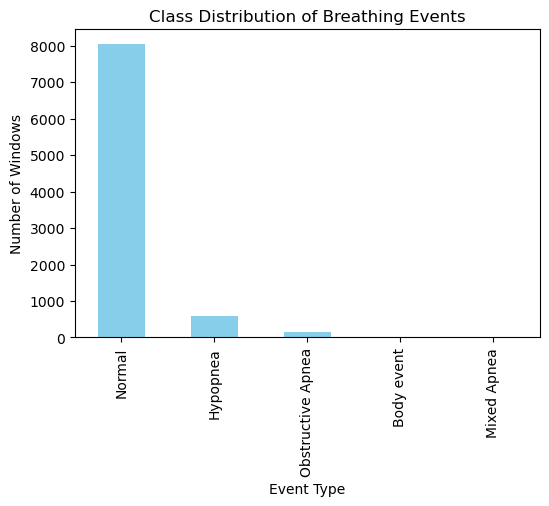

In [26]:
plt.figure(figsize=(6,4))

dataset["label"].value_counts().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Class Distribution of Breathing Events")
plt.xlabel("Event Type")
plt.ylabel("Number of Windows")

plt.show()

In [23]:
sample = dataset.iloc[0]

print("Airflow length:", len(sample["airflow"]))
print("Thoracic length:", len(sample["thoracic"]))
print("SpO2 length:", len(sample["spo2"]))

Airflow length: 960
Thoracic length: 960
SpO2 length: 120


In [24]:
bad_windows = 0

for i,row in dataset.iterrows():

    if len(row["airflow"]) != 960:
        bad_windows += 1

    if len(row["thoracic"]) != 960:
        bad_windows += 1

    if len(row["spo2"]) != 120:
        bad_windows += 1

print("Invalid windows:", bad_windows)

Invalid windows: 0


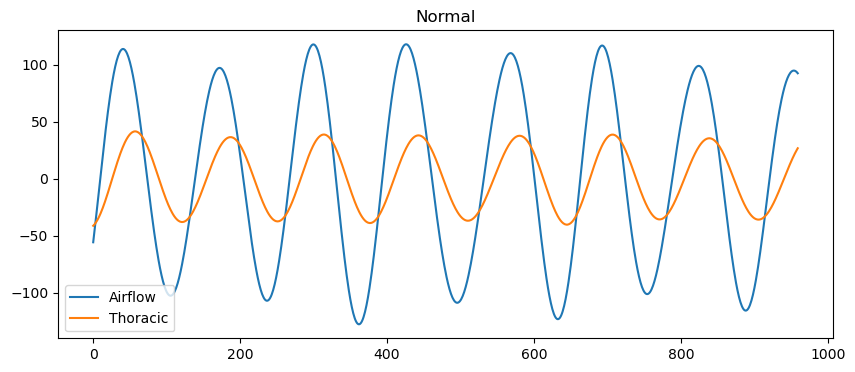

In [25]:
import matplotlib.pyplot as plt

sample = dataset.sample(1).iloc[0]

plt.figure(figsize=(10,4))

plt.plot(sample["airflow"], label="Airflow")
plt.plot(sample["thoracic"], label="Thoracic")

plt.title(sample["label"])
plt.legend()

plt.show()

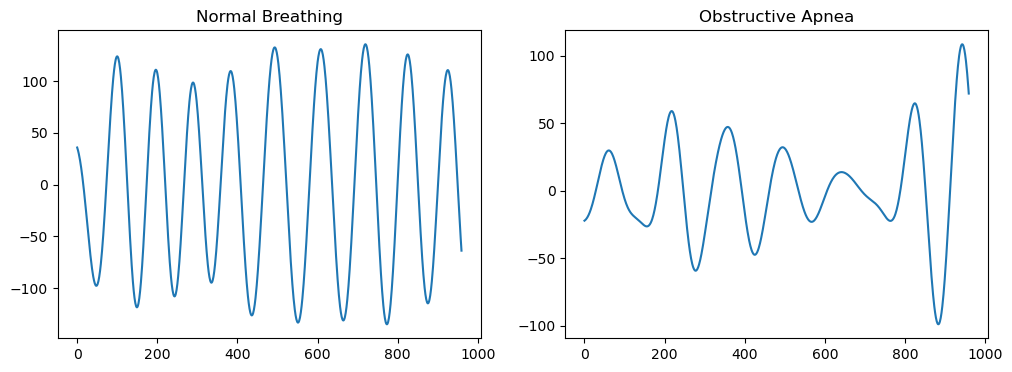

In [28]:
sample_normal = dataset[dataset["label"]=="Normal"].iloc[0]
sample_apnea = dataset[dataset["label"]=="Obstructive Apnea"].iloc[0]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(sample_normal["airflow"])
plt.title("Normal Breathing")

plt.subplot(1,2,2)
plt.plot(sample_apnea["airflow"])
plt.title("Obstructive Apnea")
output_path=r"C:\Users\apurb_oi8roye\Desktop\Health_sensing\Visualizations\Normal_Obstructive"
plt.savefig(output_path)
plt.show()